In [1]:
import pandas as pd
import numpy as np
import obspy
from seismicif.datamod.loading_utils import (
    find_paths,
    preproc_flow_annotations,
    find_date_in_strings,
)
from seismicif.datamod.preproc_utils import preproc_stream

In [4]:
np.arange(0.50, 0.66, 0.01)

array([0.5 , 0.51, 0.52, 0.53, 0.54, 0.55, 0.56, 0.57, 0.58, 0.59, 0.6 ,
       0.61, 0.62, 0.63, 0.64, 0.65, 0.66])

In [23]:
for y in [2018, 2019, 2020, 2021, 2022]:
    try:
        print(y, find_paths("XP", "ILL18", "EHZ.D", y, y).shape)
    except:
        continue

2018 (181,)
2019 (197,)
2020 (239,)
2021 (203,)
2022 (168,)


In [ ]:
# 25  2018-05-30T17:15:03.740003Z  2018-05-30T18:14:13.740003Z  7152.889770    3550.0
# 27  2018-10-31T11:48:25.470000Z  2018-10-31T12:26:45.470000Z  7463.154286    2300.0,

In [100]:
streams = obspy.Stream()
t0 = obspy.UTCDateTime("2018-05-30T16:15:03.740003Z")
t1 = obspy.UTCDateTime("2018-05-30T19:14:13.740003Z")

paths = find_paths("XP", "ILL18", "EHZ.D", 2018, 2018)
p = find_date_in_strings(paths, "2018-05-30")[0]
st = obspy.read(p)
preproc_stream(st)
st.trim(t0, t1)
streams += st

paths = find_paths("XP", "ILL17", "EHZ.D", 2018, 2018)
p = find_date_in_strings(paths, "2018-05-30")[0]
st = obspy.read(p)
preproc_stream(st)
st.trim(t0, t1)
streams += st

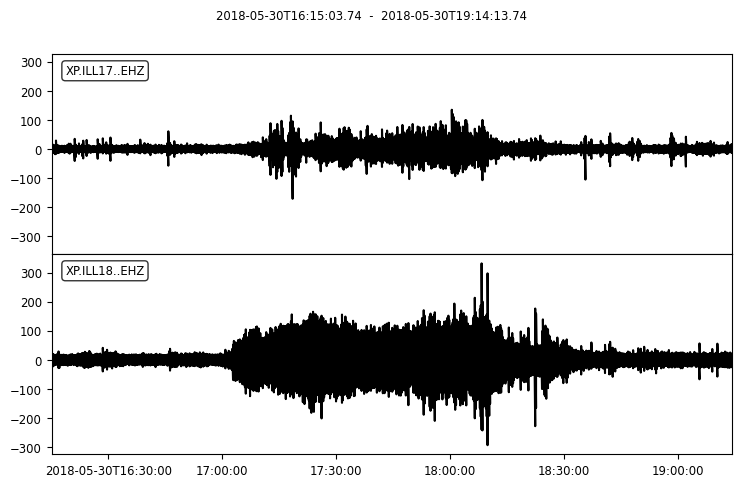

c:\Users\franc\anaconda3\envs\seismic-if-env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  fig.canvas.print_figure(bytes_io, **kw)


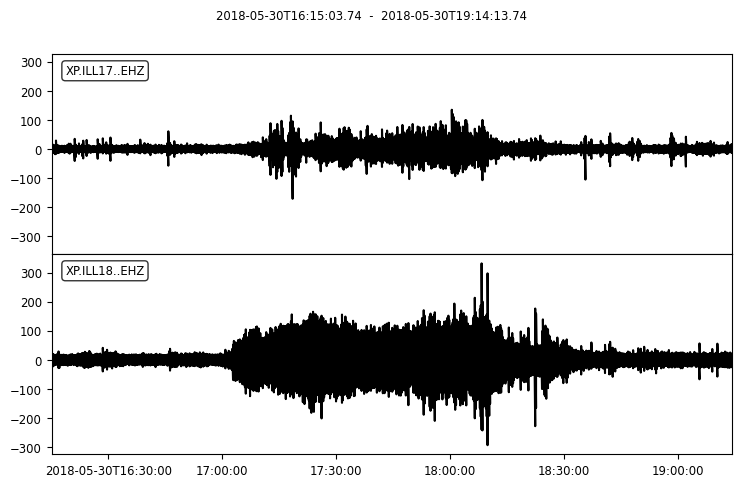

In [101]:
streams.plot()

In [118]:
t0 = obspy.UTCDateTime("2018-10-31T9:48:25.470000Z")
t1 = obspy.UTCDateTime("2018-10-31T13:26:45.470000Z")

paths = find_paths("XP", "ILL18", "EHZ.D", 2018, 2018)
p = find_date_in_strings(paths, "2018-10-31")[0]
st = obspy.read(p)
preproc_stream(st)

1 Trace(s) in Stream:
XP.ILL18..EHZ | 2018-10-31T00:00:00.000000Z - 2018-10-31T23:59:59.990000Z | 100.0 Hz, 8640000 samples

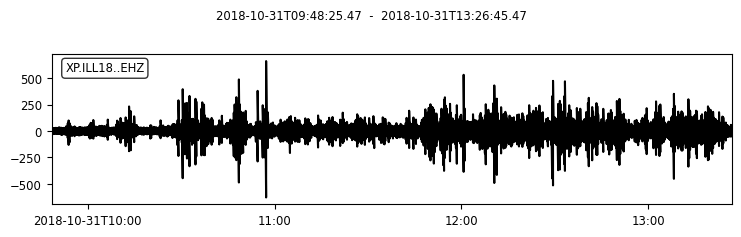

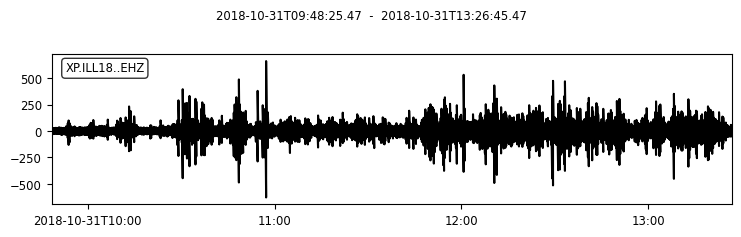

In [119]:
st.trim(t0, t1).plot()

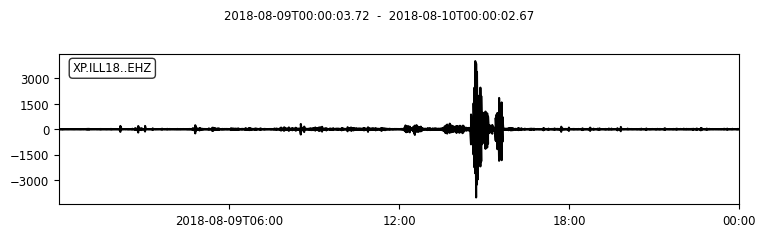

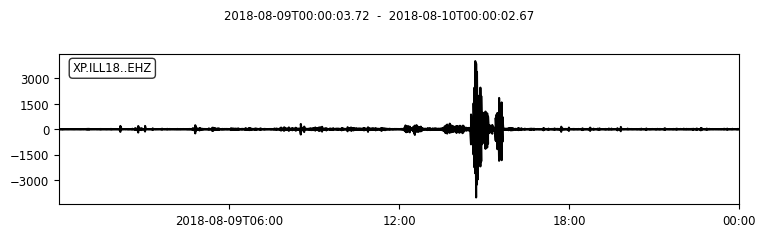

In [123]:
paths = find_paths("XP", "ILL18", "EHZ.D", 2018, 2018)
p = find_date_in_strings(paths, "2018-08-09")[0]
st = obspy.read(p)
preproc_stream(st)
st.plot()

In [22]:
scores_df = pd.read_csv("../output/if_scores/ILL18.csv", index_col=0)
scores_old = pd.read_csv("../output/if_scores_old/ILL18.csv", index_col=0)

In [23]:
vals = []
for i in range(scores_old["anomaly_score"].shape[0]):
    vals.append(np.abs(scores_df["anomaly_score"][i] - scores_old["anomaly_score"][i]))

    if vals[-1] > 1e-10:
        print("Fail")

In [24]:
np.max(vals)

2.7755575615628914e-16

In [13]:
np.abs(scores_df["anomaly_score"][i] - scores_old["anomaly_score"][i])

0.0

0.00032043985516799767

In [ ]:
scores_old["anomaly_score"][i]

0.4031680296061047

In [26]:
scores_df["anomaly_score"].shape

(1650396,)

In [27]:
scores_old["anomaly_score"].shape

(1650396,)

In [73]:
np.abs(scores_df["anomaly_score"][i] - scores_old["anomaly_score"][i])

0.0

In [49]:
scores_df.iloc[i,]

start            2022-08-26T21:50:02.110000Z
stop             2022-08-26T21:51:42.110000Z
anomaly_score                       0.345971
std                                71.421781
Name: 1133196, dtype: object

In [50]:
scores_old.iloc[i,]

start            2022-08-26T21:50:02.110000Z
stop             2022-08-26T21:51:42.110000Z
anomaly_score                       0.345971
std                                71.421781
Name: 1133196, dtype: object